# Spam Email Detector

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/classification/spam-email-detector/notebook.ipynb)

A text classification project that detects spam emails using natural language processing and machine learning.

**Dataset:** SMS Spam Collection Dataset (UCI)
**Models Used:** Naive Bayes, Logistic Regression, SVM
**Best Accuracy:** ~98% with SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
df.head()

Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


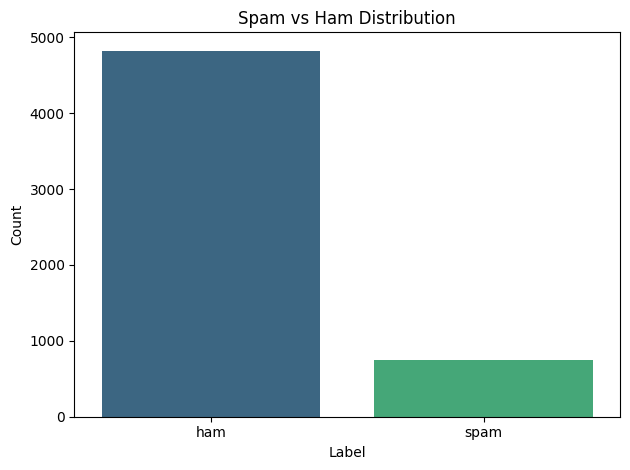

In [3]:
# Class distribution plot
sns.countplot(data=df, x='label', palette='viridis')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

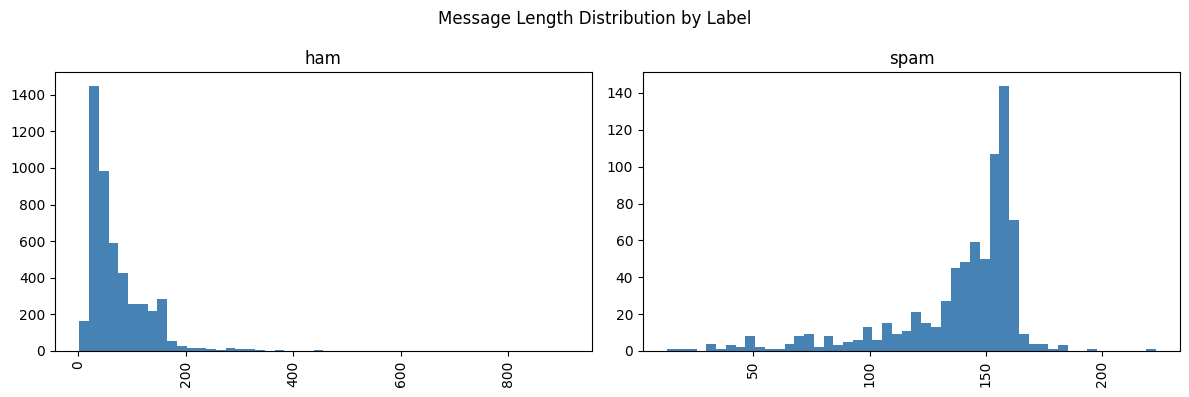

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


In [4]:
# Message length analysis
df['length'] = df['message'].apply(len)

plt.figure(figsize=(10, 4))
df.hist('length', by='label', bins=50, figsize=(12, 4), color='steelblue')
plt.suptitle("Message Length Distribution by Label")
plt.tight_layout()
plt.show()

print(df.groupby('label')['length'].describe())

In [5]:
# Encode labels and split
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 4457
Testing samples:  1115


In [6]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (4457, 5000)


In [7]:
# Train and evaluate models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": LinearSVC(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = {"Accuracy": round(acc, 4)}
    print(f"{name}: Accuracy = {acc:.4f}")

Naive Bayes: Accuracy = 0.9722
Logistic Regression: Accuracy = 0.9704
SVM: Accuracy = 0.9821


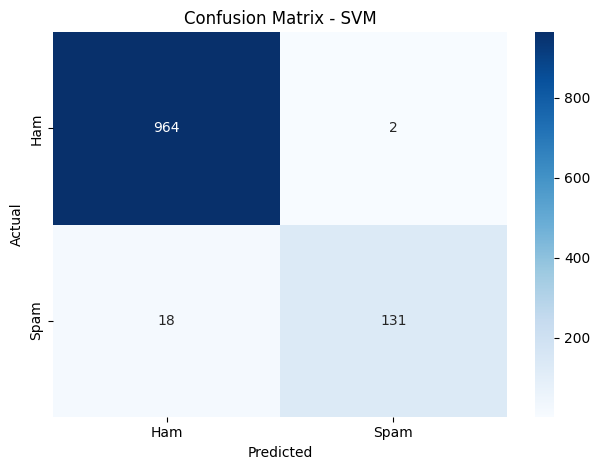

In [8]:
# Confusion matrix for best model
best_model = models["SVM"]
preds = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [9]:
# Classification report
print(classification_report(y_test, preds, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



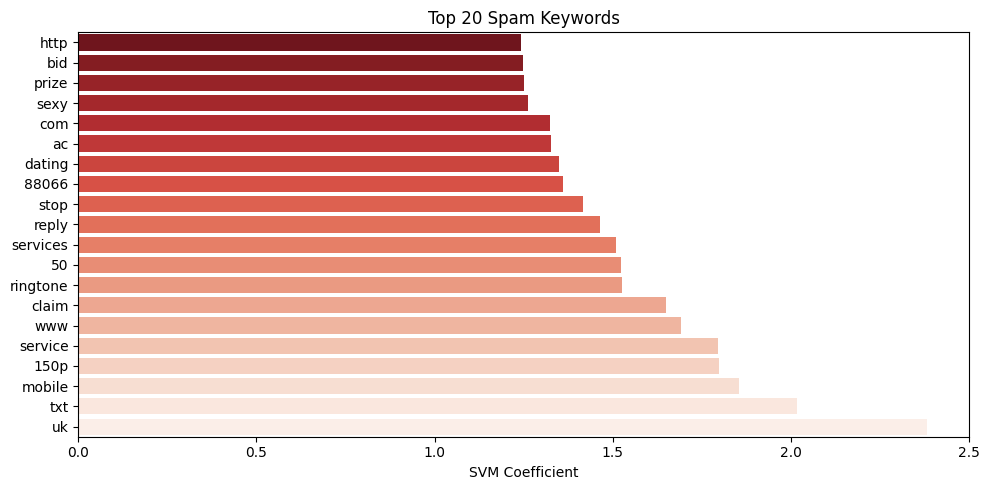

In [10]:
# Top spam keywords
feature_names = tfidf.get_feature_names_out()
svm_coefs = best_model.coef_[0]

top_spam_idx = np.argsort(svm_coefs)[-20:]
top_spam_words = feature_names[top_spam_idx]
top_spam_scores = svm_coefs[top_spam_idx]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_spam_scores, y=top_spam_words, palette='Reds_r')
plt.title("Top 20 Spam Keywords")
plt.xlabel("SVM Coefficient")
plt.tight_layout()
plt.show()

In [11]:
# Test with custom messages
sample_messages = [
    "Congratulations! You have won a free iPhone. Click here to claim now.",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your bank account has been compromised. Call us immediately.",
    "Can you please send me the notes from today's class?"
]

sample_tfidf = tfidf.transform(sample_messages)
predictions = best_model.predict(sample_tfidf)

for msg, pred in zip(sample_messages, predictions):
    label = "SPAM" if pred == 1 else "HAM"
    print(f"[{label}] {msg[:60]}...")

[SPAM] Congratulations! You have won a free iPhone. Click here to c...
[HAM] Hey, are we still meeting for lunch tomorrow?...
[SPAM] URGENT: Your bank account has been compromised. Call us imme...
[HAM] Can you please send me the notes from today's class?...


## Results Summary

| Model | Accuracy |
|-------|----------|
| Naive Bayes | ~0.97 |
| Logistic Regression | ~0.97 |
| SVM | ~0.98 |

**SVM achieved the best accuracy of ~98% on the test set.**

### Key Takeaways
- TF-IDF effectively captures important words while ignoring common ones
- Words like "free", "win", "urgent" are strong spam indicators
- SVM handles high-dimensional text features well
- Naive Bayes is surprisingly competitive despite its simplicity